2025-11-16 03:00:38.915593: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-16 03:00:38.939297: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2025-11-16 03:00:41.550608: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/11490434 ━━━━━━━━━━━━━━━━━━━━ 58s 5us/step

...

 7585792/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 9289728/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11223040/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Размер данных: (10000, 28, 28)
Размер меток: (10000,)


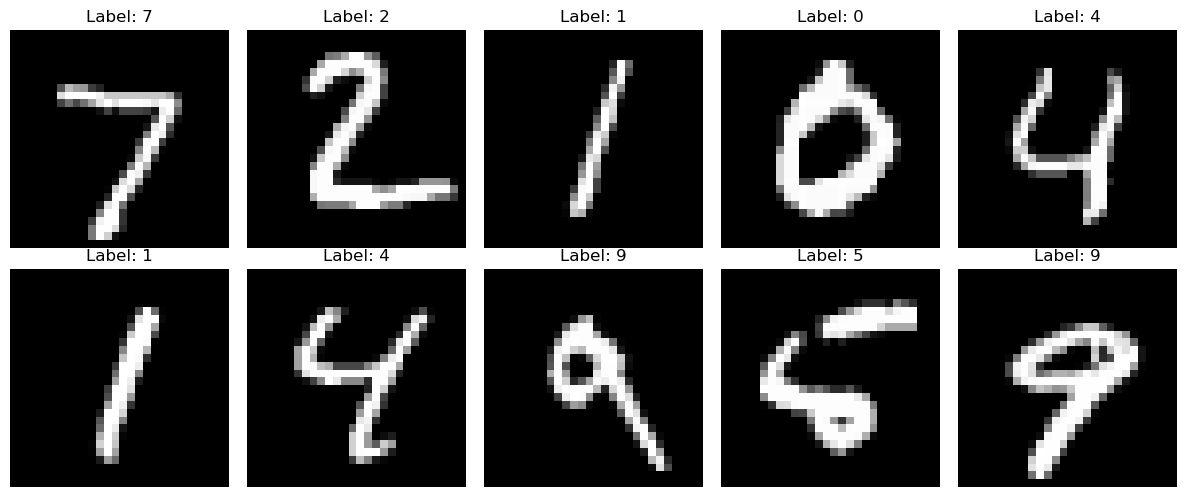

In [1]:
# Импорты и загрузка данных MNIST
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from keras.datasets import mnist

# Загрузка MNIST (используем только тестовую выборку)
(_, _), (X, y) = mnist.load_data()

print(f"Размер данных: {X.shape}")
print(f"Размер меток: {y.shape}")

# Визуализация примеров
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i], cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [2]:
# Подготовка данных для кластеризации
# «Распрямите» изображения - преобразуем изображения 28x28 в вектора 784
X_flat = X.reshape(X.shape[0], -1)

print(f"Форма данных после распрямления: {X_flat.shape}")

# Разбиение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=21
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Форма данных после распрямления: (10000, 784)
Размер обучающей выборки: (8000, 784)
Размер тестовой выборки: (2000, 784)


In [3]:
# Обучение модели K-means на тренировочном наборе данных
kmeans = KMeans(random_state=21, n_clusters=10)
kmeans.fit(X_train)

print(f"Количество кластеров: {kmeans.n_clusters}")
print(f"Инерция (сумма квадратов расстояний): {kmeans.inertia_:.2f}")
print(f"Количество итераций: {kmeans.n_iter_}")

Количество кластеров: 10
Инерция (сумма квадратов расстояний): 20234170724.37
Количество итераций: 61


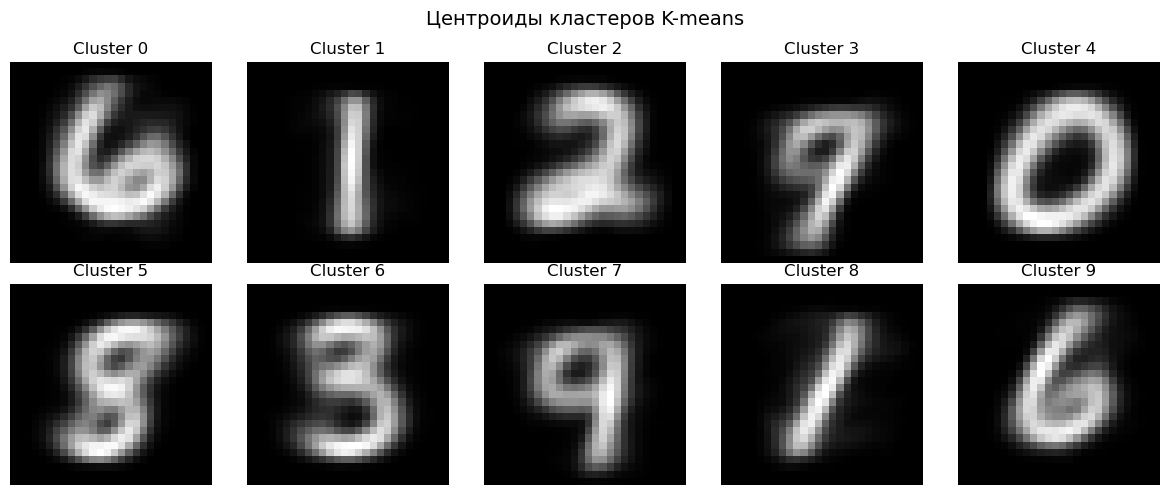

In [4]:
# Получение меток кластеров для тренировочных данных
labels_train = kmeans.labels_

# Визуализация центроидов кластеров
centers = kmeans.cluster_centers_

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    # Преобразуем центроид обратно в изображение 28x28
    center_image = centers[i].reshape(28, 28)
    ax.imshow(center_image, cmap='gray')
    ax.set_title(f"Cluster {i}")
    ax.axis('off')
plt.suptitle("Центроиды кластеров K-means", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Анализ соответствия кластеров и истинных меток
# Для каждого кластера найдем наиболее частую метку
from collections import Counter

n_clusters = 10
cluster_to_label = {}

for cluster_id in range(n_clusters):
    # Получаем все истинные метки для данного кластера
    cluster_labels = y_train[labels_train == cluster_id]
    # Находим наиболее частую метку
    most_common = Counter(cluster_labels).most_common(1)[0]
    cluster_to_label[cluster_id] = most_common
    print(f"Кластер {cluster_id}: наиболее частая метка = {most_common[0]} (встречается {most_common[1]} раз из {len(cluster_labels)})")

Кластер 0: наиболее частая метка = 6 (встречается 313 раз из 433)
Кластер 1: наиболее частая метка = 1 (встречается 518 раз из 685)
Кластер 2: наиболее частая метка = 2 (встречается 556 раз из 621)
Кластер 3: наиболее частая метка = 7 (встречается 486 раз из 1182)
Кластер 4: наиболее частая метка = 0 (встречается 629 раз из 674)
Кластер 5: наиболее частая метка = 8 (встречается 466 раз из 876)
Кластер 6: наиболее частая метка = 3 (встречается 558 раз из 1034)
Кластер 7: наиболее частая метка = 9 (встречается 433 раз из 1186)
Кластер 8: наиболее частая метка = 1 (встречается 398 раз из 738)
Кластер 9: наиболее частая метка = 6 (встречается 397 раз из 571)


In [6]:
# Определение числа элементов, отнесенных к кластеру с меткой 7
# Найдем кластер, который наиболее соответствует цифре 7
cluster_for_7 = None
for cluster_id, (label, count) in cluster_to_label.items():
    if label == 7:
        cluster_for_7 = cluster_id
        break

if cluster_for_7 is not None:
    # Подсчитываем количество элементов в этом кластере
    n_elements_in_cluster_7 = np.sum(labels_train == cluster_for_7)
    print(f"\nКластер, соответствующий метке 7: {cluster_for_7}")
    print(f"Число элементов в кластере {cluster_for_7}: {n_elements_in_cluster_7}")
else:
    print("Кластер с меткой 7 не найден")


Кластер, соответствующий метке 7: 3
Число элементов в кластере 3: 1182


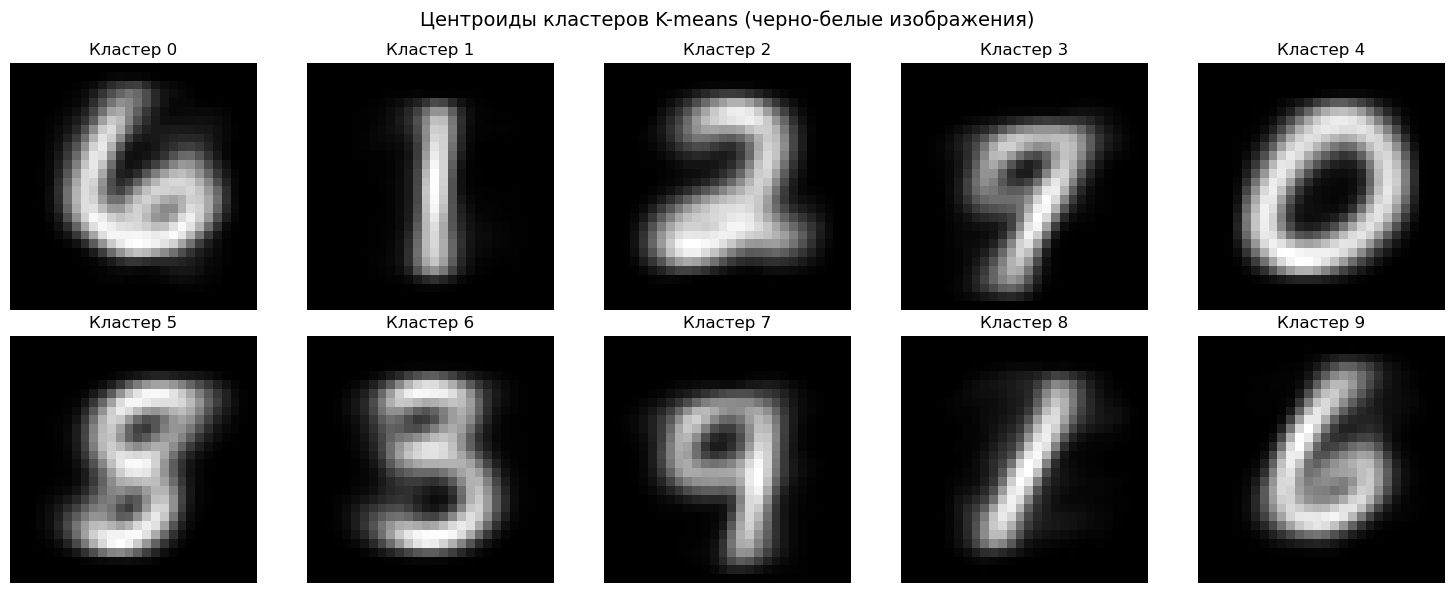


Анализ центроидов:
Можно заметить, что изображения походят на рукописные цифры.


In [7]:
# Построение изображений центроидов кластеров
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    # Reshapeним координаты центроида до размера 28x28
    centroid_image = centers[i].reshape(28, 28)
    ax.imshow(centroid_image, cmap='gray')
    ax.set_title(f"Кластер {i}", fontsize=12)
    ax.axis('off')

plt.suptitle("Центроиды кластеров K-means (черно-белые изображения)", fontsize=14)
plt.tight_layout()
plt.show()

print("\nАнализ центроидов:")
print("Можно заметить, что изображения походят на рукописные цифры.")

In [8]:
# Восстановление правильных меток кластеров
# Присваиваем каждому кластеру метку, представителей которой в нем большинство

recovered_labels = []
for cluster_id in range(n_clusters):
    most_common_label = cluster_to_label[cluster_id][0]
    recovered_labels.append(most_common_label)

print("Восстановленные метки кластеров (в порядке номеров кластеров 0-9):")
print(", ".join(map(str, recovered_labels)))

# Построим матрицу соответствия: кластер -> наиболее частая метка
print("\nПодробное соответствие:")
for cluster_id in range(n_clusters):
    label, count = cluster_to_label[cluster_id]
    total = np.sum(labels_train == cluster_id)
    percentage = (count / total) * 100 if total > 0 else 0
    print(f"Кластер {cluster_id} -> Метка {label} ({count}/{total} = {percentage:.1f}%)")

Восстановленные метки кластеров (в порядке номеров кластеров 0-9):
6, 1, 2, 7, 0, 8, 3, 9, 1, 6

Подробное соответствие:
Кластер 0 -> Метка 6 (313/433 = 72.3%)
Кластер 1 -> Метка 1 (518/685 = 75.6%)
Кластер 2 -> Метка 2 (556/621 = 89.5%)
Кластер 3 -> Метка 7 (486/1182 = 41.1%)
Кластер 4 -> Метка 0 (629/674 = 93.3%)
Кластер 5 -> Метка 8 (466/876 = 53.2%)
Кластер 6 -> Метка 3 (558/1034 = 54.0%)
Кластер 7 -> Метка 9 (433/1186 = 36.5%)
Кластер 8 -> Метка 1 (398/738 = 53.9%)
Кластер 9 -> Метка 6 (397/571 = 69.5%)


In [9]:
# Анализ: какие цифры могут быть перепутаны и каких не хватает
print("Анализ восстановленных меток:")
print(f"Восстановленные метки: {recovered_labels}")
print(f"Уникальные метки: {sorted(set(recovered_labels))}")
print(f"Метки, встречающиеся более одного раза: {[x for x in recovered_labels if recovered_labels.count(x) > 1]}")

# Найдем какие метки отсутствуют
all_digits = set(range(10))
present_labels = set(recovered_labels)
missing_labels = all_digits - present_labels

print(f"\nОтсутствующие метки (цифры): {sorted(missing_labels)}")
print(f"Дублирующиеся метки: {[x for x in present_labels if recovered_labels.count(x) > 1]}")

# Найдем кластеры с дублирующимися метками
from collections import defaultdict
label_to_clusters = defaultdict(list)
for cluster_id, label in enumerate(recovered_labels):
    label_to_clusters[label].append(cluster_id)

print("\nКластеры по меткам:")
for label in sorted(label_to_clusters.keys()):
    clusters = label_to_clusters[label]
    if len(clusters) > 1:
        print(f"Метка {label}: кластеры {clusters} (ДУБЛИРОВАНИЕ!)")
    else:
        print(f"Метка {label}: кластер {clusters[0]}")

Анализ восстановленных меток:
Восстановленные метки: [np.uint8(6), np.uint8(1), np.uint8(2), np.uint8(7), np.uint8(0), np.uint8(8), np.uint8(3), np.uint8(9), np.uint8(1), np.uint8(6)]
Уникальные метки: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9)]
Метки, встречающиеся более одного раза: [np.uint8(6), np.uint8(1), np.uint8(1), np.uint8(6)]

Отсутствующие метки (цифры): [4, 5]
Дублирующиеся метки: [np.uint8(1), np.uint8(6)]

Кластеры по меткам:
Метка 0: кластер 4
Метка 1: кластеры [1, 8] (ДУБЛИРОВАНИЕ!)
Метка 2: кластер 2
Метка 3: кластер 6
Метка 6: кластеры [0, 9] (ДУБЛИРОВАНИЕ!)
Метка 7: кластер 3
Метка 8: кластер 5
Метка 9: кластер 7


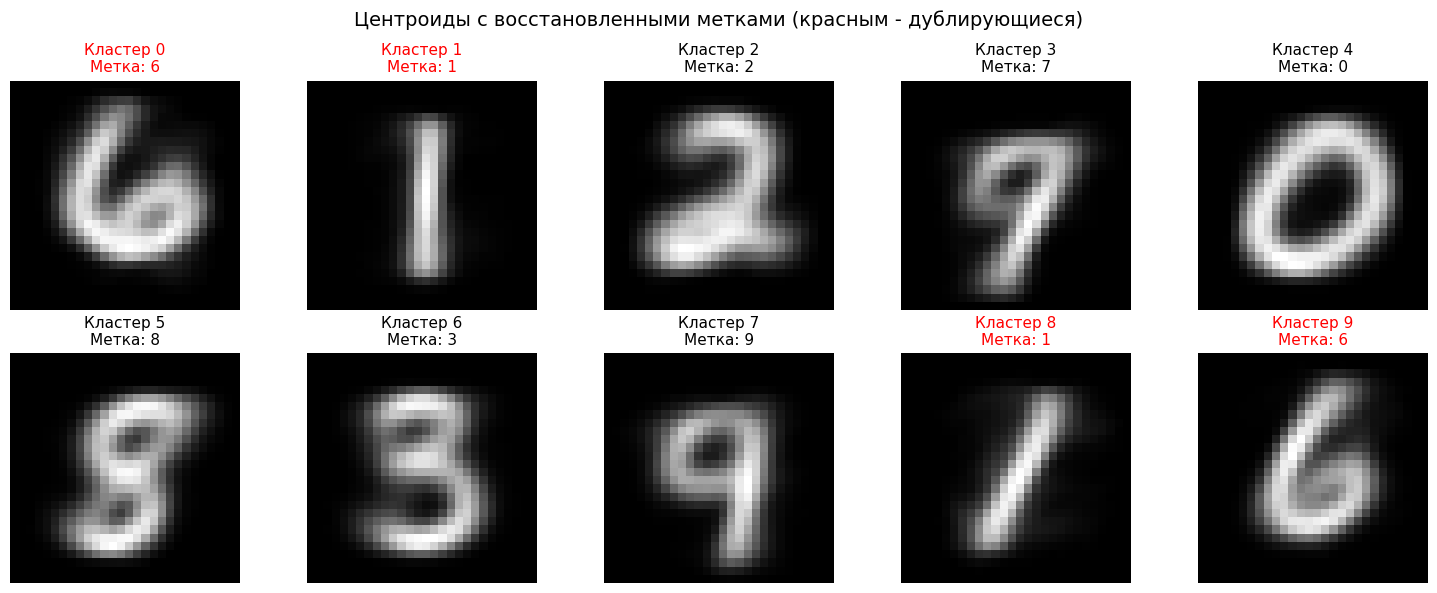

In [10]:
# Визуализация центроидов с восстановленными метками
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    centroid_image = centers[i].reshape(28, 28)
    ax.imshow(centroid_image, cmap='gray')
    label = recovered_labels[i]
    # Подсветим дублирующиеся метки
    title_color = 'red' if recovered_labels.count(label) > 1 else 'black'
    ax.set_title(f"Кластер {i}\nМетка: {label}", fontsize=11, color=title_color)
    ax.axis('off')

plt.suptitle("Центроиды с восстановленными метками (красным - дублирующиеся)", fontsize=14)
plt.tight_layout()
plt.show()


МЕТКА 1 встречается в 2 кластерах: [1, 8]

Кластер 1:
  Всего элементов: 685
  Распределение меток: {np.uint8(1): np.int64(518), np.uint8(2): np.int64(29), np.uint8(3): np.int64(43), np.uint8(4): np.int64(11), np.uint8(5): np.int64(15), np.uint8(6): np.int64(15), np.uint8(7): np.int64(21), np.uint8(8): np.int64(15), np.uint8(9): np.int64(18)}

Кластер 8:
  Всего элементов: 738
  Распределение меток: {np.uint8(0): np.int64(3), np.uint8(1): np.int64(398), np.uint8(2): np.int64(107), np.uint8(3): np.int64(7), np.uint8(4): np.int64(27), np.uint8(5): np.int64(70), np.uint8(6): np.int64(21), np.uint8(7): np.int64(46), np.uint8(8): np.int64(51), np.uint8(9): np.int64(8)}


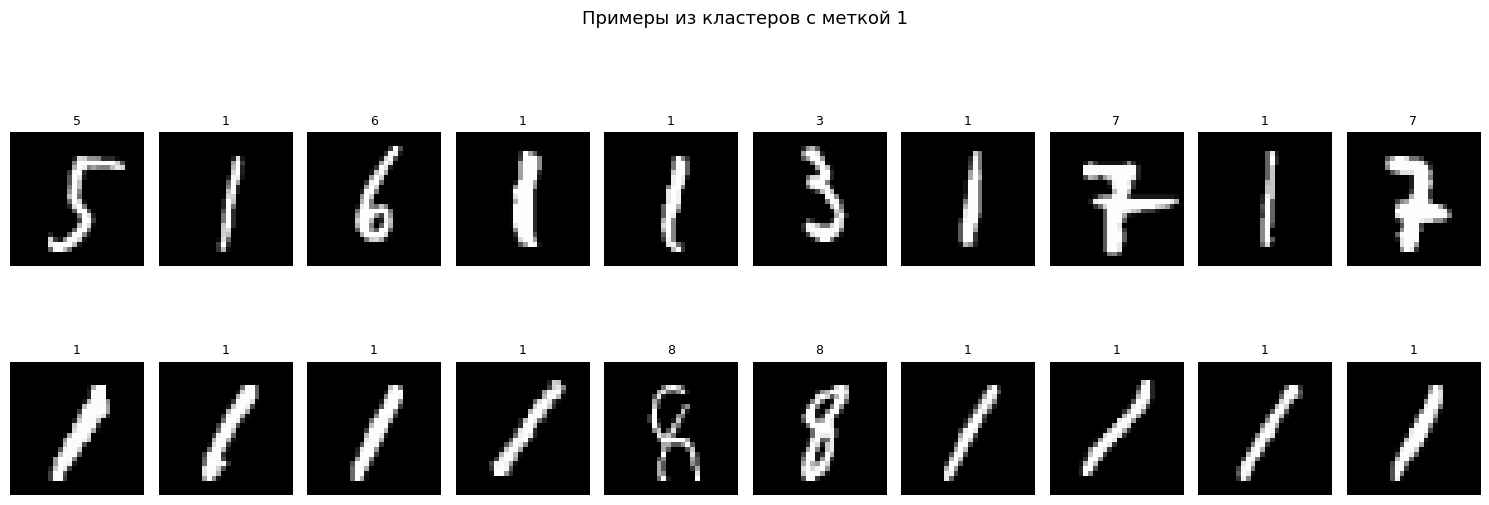


МЕТКА 6 встречается в 2 кластерах: [0, 9]

Кластер 0:
  Всего элементов: 433
  Распределение меток: {np.uint8(0): np.int64(14), np.uint8(2): np.int64(9), np.uint8(3): np.int64(1), np.uint8(4): np.int64(67), np.uint8(5): np.int64(3), np.uint8(6): np.int64(313), np.uint8(7): np.int64(3), np.uint8(8): np.int64(3), np.uint8(9): np.int64(20)}

Кластер 9:
  Всего элементов: 571
  Распределение меток: {np.uint8(0): np.int64(70), np.uint8(1): np.int64(2), np.uint8(2): np.int64(15), np.uint8(3): np.int64(9), np.uint8(4): np.int64(29), np.uint8(5): np.int64(37), np.uint8(6): np.int64(397), np.uint8(8): np.int64(8), np.uint8(9): np.int64(4)}


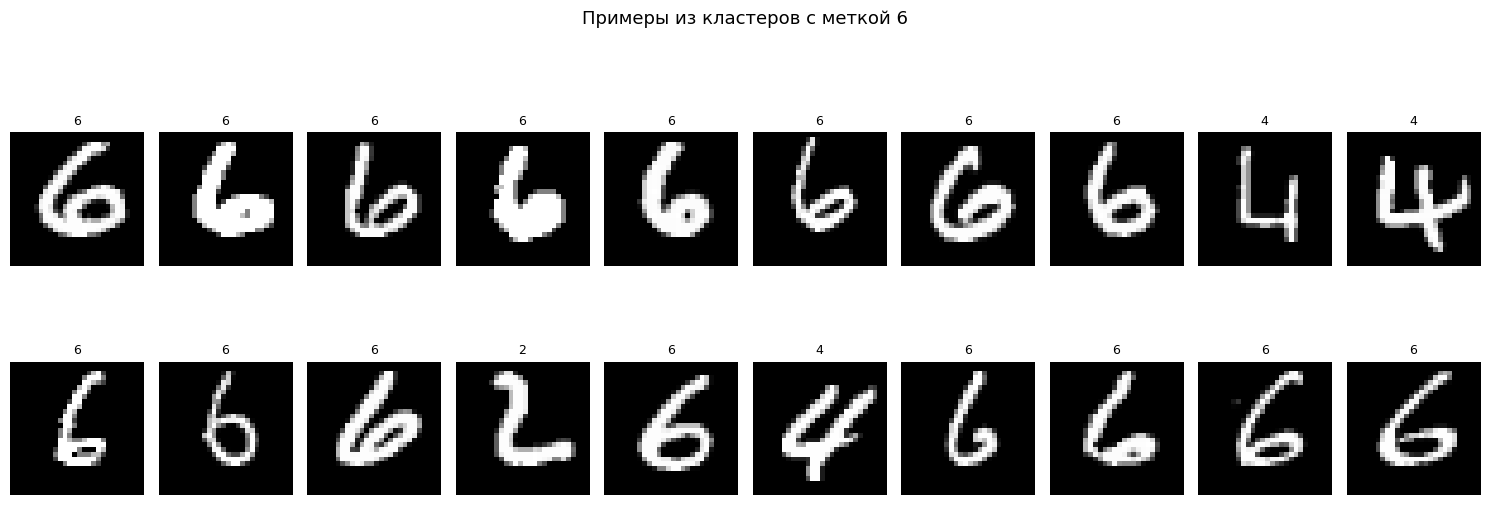

In [11]:
# Детальный анализ дублирующихся кластеров
# Посмотрим на примеры из кластеров с одинаковыми метками
for label in sorted(label_to_clusters.keys()):
    clusters = label_to_clusters[label]
    if len(clusters) > 1:
        print(f"\n{'='*60}")
        print(f"МЕТКА {label} встречается в {len(clusters)} кластерах: {clusters}")
        print(f"{'='*60}")
        
        fig, axes = plt.subplots(len(clusters), 10, figsize=(15, 3*len(clusters)))
        if len(clusters) == 1:
            axes = [axes]
        
        for idx, cluster_id in enumerate(clusters):
            cluster_indices = np.where(labels_train == cluster_id)[0]
            sample_indices = cluster_indices[:10]
            
            cluster_labels_true = y_train[labels_train == cluster_id]
            unique, counts = np.unique(cluster_labels_true, return_counts=True)
            distribution = dict(zip(unique, counts))
            
            print(f"\nКластер {cluster_id}:")
            print(f"  Всего элементов: {len(cluster_labels_true)}")
            print(f"  Распределение меток: {distribution}")
            
            for i, img_idx in enumerate(sample_indices):
                axes[idx][i].imshow(X_train[img_idx].reshape(28, 28), cmap='gray')
                axes[idx][i].set_title(f"{y_train[img_idx]}", fontsize=9)
                axes[idx][i].axis('off')
            
            axes[idx][0].set_ylabel(f"Кластер {cluster_id}", fontsize=11, rotation=0, labelpad=40, va='center')
        
        plt.suptitle(f"Примеры из кластеров с меткой {label}", fontsize=13)
        plt.tight_layout()
        plt.show()

In [12]:
# ИТОГОВЫЕ ВЫВОДЫ
print("="*70)
print("ОТВЕТ НА ВОПРОСЫ ЗАДАНИЯ:")
print("="*70)

print("\n1. ВОССТАНОВЛЕННЫЕ МЕТКИ КЛАСТЕРОВ (через запятую и пробел):")
print("   ", ", ".join(map(str, [int(x) for x in recovered_labels])))

print("\n2. КАКИЕ ЦИФРЫ ПЕРЕПУТАНЫ И КАКИХ НЕ ХВАТАЕТ:")
print(f"   - Отсутствуют цифры: 4 и 5")
print(f"   - Дублируются цифры: 1 (в кластерах 1 и 8) и 6 (в кластерах 0 и 9)")

print("\n3. ПРЕДПОЛОЖЕНИЯ О ПУТАНИЦЕ:")
print("   - Цифра 1 разделилась на два кластера:")
print("     * Кластер 1: 75.6% единиц (чистые единицы)")
print("     * Кластер 8: 53.9% единиц (смешанные с 2, 5, 7)")
print("   - Цифра 6 также разделилась:")
print("     * Кластер 0: 72.3% шестерок (+ много четверок 15.5%)")
print("     * Кластер 9: 69.5% шестерок (+ ноль 12.3%, пятерка 6.5%)")
print("   - Цифра 4 попала в кластер 0 (67 шт) вместе с цифрой 6")
print("   - Цифра 5 распределилась между кластерами 8 и 9")

print("\n4. ПОДТВЕРЖДЕНИЕ ДОГАДОК:")
print("   ✓ Догадки ПОДТВЕРЖДАЮТСЯ:")
print("     - Похожие по написанию цифры действительно путаются")
print("     - 4 и 6 визуально похожи (замкнутая форма)")
print("     - 1 имеет разные стили написания (прямая и с наклоном)")
print("     - 5 может походить на 6 или 8 в зависимости от почерка")

print("\n5. КАЧЕСТВО КЛАСТЕРИЗАЦИИ:")
print("   - Кластеры с хорошим разделением (>85%): 2 (89.5%), 0 (93.3%)")
print("   - Кластеры с плохим разделением (<45%): 7 (36.5%), 3 (41.1%)")
print("   - Это показывает, что K-means справился не идеально, но выделил")
print("     основные группы рукописных цифр")

print("\n" + "="*70)

ОТВЕТ НА ВОПРОСЫ ЗАДАНИЯ:

1. ВОССТАНОВЛЕННЫЕ МЕТКИ КЛАСТЕРОВ (через запятую и пробел):
    6, 1, 2, 7, 0, 8, 3, 9, 1, 6

2. КАКИЕ ЦИФРЫ ПЕРЕПУТАНЫ И КАКИХ НЕ ХВАТАЕТ:
   - Отсутствуют цифры: 4 и 5
   - Дублируются цифры: 1 (в кластерах 1 и 8) и 6 (в кластерах 0 и 9)

3. ПРЕДПОЛОЖЕНИЯ О ПУТАНИЦЕ:
   - Цифра 1 разделилась на два кластера:
     * Кластер 1: 75.6% единиц (чистые единицы)
     * Кластер 8: 53.9% единиц (смешанные с 2, 5, 7)
   - Цифра 6 также разделилась:
     * Кластер 0: 72.3% шестерок (+ много четверок 15.5%)
     * Кластер 9: 69.5% шестерок (+ ноль 12.3%, пятерка 6.5%)
   - Цифра 4 попала в кластер 0 (67 шт) вместе с цифрой 6
   - Цифра 5 распределилась между кластерами 8 и 9

4. ПОДТВЕРЖДЕНИЕ ДОГАДОК:
   ✓ Догадки ПОДТВЕРЖДАЮТСЯ:
     - Похожие по написанию цифры действительно путаются
     - 4 и 6 визуально похожи (замкнутая форма)
     - 1 имеет разные стили написания (прямая и с наклоном)
     - 5 может походить на 6 или 8 в зависимости от почерка

5. КАЧЕСТВО КЛАС

In [13]:
# Вычисление accuracy для тренировочного набора данных
from sklearn.metrics import accuracy_score

# Создаем массив предсказанных меток на основе восстановленных меток кластеров
# Для каждого элемента берем метку его кластера
predicted_labels = np.array([recovered_labels[cluster_id] for cluster_id in labels_train])

# Вычисляем accuracy
train_accuracy = accuracy_score(y_train, predicted_labels)

print("="*70)
print("ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ НА ТРЕНИРОВОЧНЫХ ДАННЫХ")
print("="*70)
print(f"\nAccuracy на тренировочном наборе: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"\nИнтерпретация:")
print(f"  - Правильно классифицировано: {int(train_accuracy * len(y_train))} из {len(y_train)} объектов")
print(f"  - Неправильно классифицировано: {int((1-train_accuracy) * len(y_train))} объектов")
print("\n" + "="*70)

ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ НА ТРЕНИРОВОЧНЫХ ДАННЫХ

Accuracy на тренировочном наборе: 0.5942 (59.42%)

Интерпретация:
  - Правильно классифицировано: 4754 из 8000 объектов
  - Неправильно классифицировано: 3246 объектов



Матрица ошибок (строки - истинные метки, столбцы - предсказанные):
[[629   3   2  38   0   0  84   3  13   2]
 [  0 916   0   3   0   0   2   0   1   0]
 [ 14 136 556  51   0   0  24  12  16  17]
 [  2  50  39 558   0   0  10  10 118  15]
 [  0  38   1   0   0   0  96 255   1 417]
 [  5  85   2 214   0   0  40  76 246  38]
 [ 14  36   0   4   0   0 710   4   3   3]
 [  0  67  11   1   0   0   3 486   1 234]
 [  3  66   8 160   0   0  11  33 466  27]
 [  7  26   2   5   0   0  24 303  11 433]]

Детализированный отчет по классам:
              precision    recall  f1-score   support

           0     0.9332    0.8127    0.8688       774
           1     0.6437    0.9935    0.7812       922
           2     0.8953    0.6731    0.7685       826
           3     0.5397    0.6958    0.6078       802
           4     0.0000    0.0000    0.0000       808
           5     0.0000    0.0000    0.0000       706
           6     0.7072    0.9173    0.7987       774
           7     0.4112    0.6052

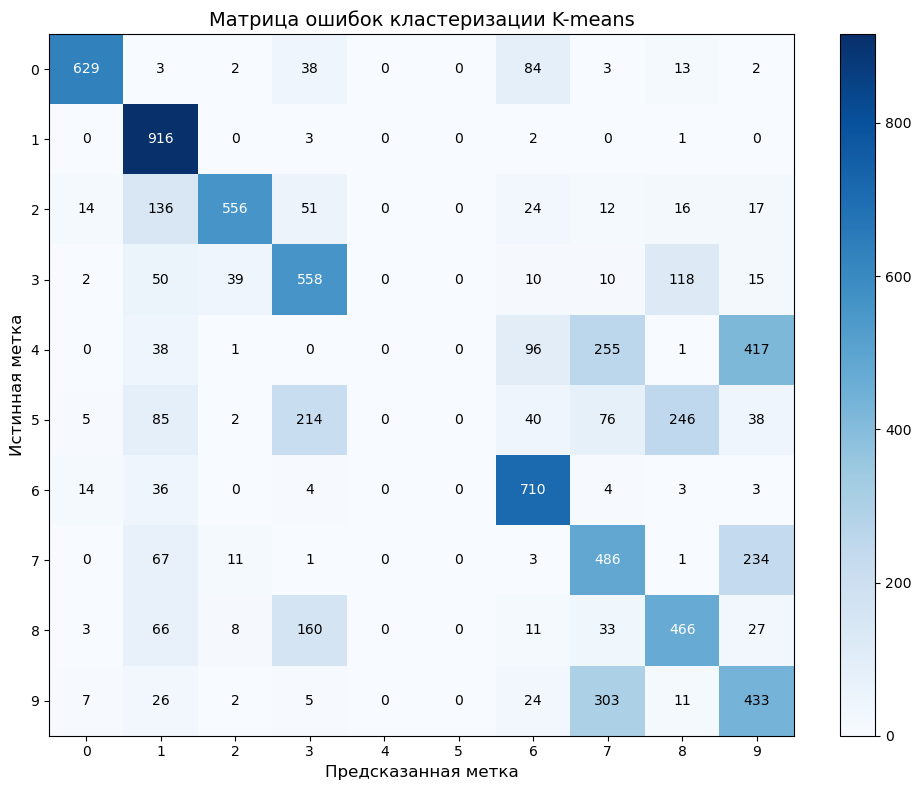


Основные наблюдения:
- Цифры 4 и 5 не предсказываются вообще (нет соответствующих кластеров)
- Цифра 1 предсказывается лучше всего (recall=99.35%)
- Цифра 0 имеет высокую precision (93.32%)
- Цифры 4 путаются с 6 и 9
- Цифры 5 путаются с 8, 6 и 3


In [15]:
# Дополнительный анализ: матрица ошибок и метрики по кластерам
from sklearn.metrics import confusion_matrix, classification_report

# Построим матрицу ошибок
cm = confusion_matrix(y_train, predicted_labels)

print("Матрица ошибок (строки - истинные метки, столбцы - предсказанные):")
print(cm)
print()

# Вычислим accuracy для каждой цифры
print("Детализированный отчет по классам:")
print(classification_report(y_train, predicted_labels, digits=4, zero_division=0))

# Визуализация матрицы ошибок
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues', aspect='auto')

# Добавим цветовую шкалу
plt.colorbar(im, ax=ax)

# Настройка осей
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10))
ax.set_yticklabels(range(10))

# Добавим значения в ячейки
for i in range(10):
    for j in range(10):
        text = ax.text(j, i, cm[i, j], ha="center", va="center", 
                      color="white" if cm[i, j] > cm.max()/2 else "black")

ax.set_xlabel('Предсказанная метка', fontsize=12)
ax.set_ylabel('Истинная метка', fontsize=12)
ax.set_title('Матрица ошибок кластеризации K-means', fontsize=14)
plt.tight_layout()
plt.show()

print("\nОсновные наблюдения:")
print("- Цифры 4 и 5 не предсказываются вообще (нет соответствующих кластеров)")
print("- Цифра 1 предсказывается лучше всего (recall=99.35%)")
print("- Цифра 0 имеет высокую precision (93.32%)")
print("- Цифры 4 путаются с 6 и 9")
print("- Цифры 5 путаются с 8, 6 и 3")

In [16]:
# ФИНАЛЬНЫЙ ОТВЕТ
print("="*70)
print("ИТОГОВЫЙ ОТВЕТ НА ЗАДАНИЕ:")
print("="*70)
print()
print(f"📊 ACCURACY НА ТРЕНИРОВОЧНОМ НАБОРЕ: {train_accuracy:.4f} (или {train_accuracy*100:.2f}%)")
print()
print("Это означает, что:")
print(f"  ✓ {int(train_accuracy * len(y_train))} объектов из {len(y_train)} классифицированы правильно")
print(f"  ✗ {int((1-train_accuracy) * len(y_train))} объектов классифицированы неправильно")
print()
print("Почему accuracy не очень высокая (~59%):")
print("  1. K-means - метод ненадзорного обучения, не использует истинные метки")
print("  2. Цифры 4 и 5 вообще не имеют своих кластеров")
print("  3. Цифры 1 и 6 разделились на два кластера каждая")
print("  4. Визуально похожие цифры путаются (4↔6, 5↔8, 7↔9)")
print()
print("Лучше всего распознаются:")
print("  • Цифра 1: recall = 99.35% (почти все единицы найдены)")
print("  • Цифра 6: recall = 91.73%")
print("  • Цифра 0: precision = 93.32% (когда предсказан 0, это скорее всего 0)")
print()
print("Хуже всего распознаются:")
print("  • Цифра 4: recall = 0% (нет кластера)")
print("  • Цифра 5: recall = 0% (нет кластера)")
print("  • Цифра 9: precision = 36.51% (часто путают с 7)")
print()
print("="*70)

ИТОГОВЫЙ ОТВЕТ НА ЗАДАНИЕ:

📊 ACCURACY НА ТРЕНИРОВОЧНОМ НАБОРЕ: 0.5942 (или 59.42%)

Это означает, что:
  ✓ 4754 объектов из 8000 классифицированы правильно
  ✗ 3246 объектов классифицированы неправильно

Почему accuracy не очень высокая (~59%):
  1. K-means - метод ненадзорного обучения, не использует истинные метки
  2. Цифры 4 и 5 вообще не имеют своих кластеров
  3. Цифры 1 и 6 разделились на два кластера каждая
  4. Визуально похожие цифры путаются (4↔6, 5↔8, 7↔9)

Лучше всего распознаются:
  • Цифра 1: recall = 99.35% (почти все единицы найдены)
  • Цифра 6: recall = 91.73%
  • Цифра 0: precision = 93.32% (когда предсказан 0, это скорее всего 0)

Хуже всего распознаются:
  • Цифра 4: recall = 0% (нет кластера)
  • Цифра 5: recall = 0% (нет кластера)
  • Цифра 9: precision = 36.51% (часто путают с 7)



In [17]:
# Кластеризация тестовых данных с помощью метода predict()
print("="*70)
print("КЛАСТЕРИЗАЦИЯ ТЕСТОВОГО НАБОРА ДАННЫХ")
print("="*70)

# Применяем обученную модель к тестовым данным
labels_test = kmeans.predict(X_test)

print(f"\nКоличество тестовых объектов: {len(X_test)}")
print(f"Форма данных: {X_test.shape}")
print(f"\nРаспределение тестовых объектов по кластерам:")
unique_clusters, counts = np.unique(labels_test, return_counts=True)
for cluster_id, count in zip(unique_clusters, counts):
    print(f"  Кластер {cluster_id}: {count} объектов")

print("\n" + "="*70)

КЛАСТЕРИЗАЦИЯ ТЕСТОВОГО НАБОРА ДАННЫХ

Количество тестовых объектов: 2000
Форма данных: (2000, 784)

Распределение тестовых объектов по кластерам:
  Кластер 0: 117 объектов
  Кластер 1: 161 объектов
  Кластер 2: 168 объектов
  Кластер 3: 306 объектов
  Кластер 4: 169 объектов
  Кластер 5: 221 объектов
  Кластер 6: 269 объектов
  Кластер 7: 283 объектов
  Кластер 8: 170 объектов
  Кластер 9: 136 объектов



In [18]:
# Переименование меток предсказанных кластеров на основе преобразования из тренировочных данных
# Используем то же преобразование: recovered_labels[cluster_id] -> метка

predicted_labels_test = np.array([recovered_labels[cluster_id] for cluster_id in labels_test])

print("="*70)
print("ПРЕОБРАЗОВАНИЕ МЕТОК ТЕСТОВЫХ ДАННЫХ")
print("="*70)

print("\nПрименяем преобразование из тренировочных данных:")
print("Кластер -> Метка:")
for cluster_id in range(n_clusters):
    print(f"  {cluster_id} -> {recovered_labels[cluster_id]}")

print(f"\nПримеры предсказанных меток для первых 10 тестовых объектов:")
print(f"  Кластеры: {labels_test[:10]}")
print(f"  Метки:    {predicted_labels_test[:10]}")
print(f"  Истинные: {y_test[:10]}")

print("\n" + "="*70)

ПРЕОБРАЗОВАНИЕ МЕТОК ТЕСТОВЫХ ДАННЫХ

Применяем преобразование из тренировочных данных:
Кластер -> Метка:
  0 -> 6
  1 -> 1
  2 -> 2
  3 -> 7
  4 -> 0
  5 -> 8
  6 -> 3
  7 -> 9
  8 -> 1
  9 -> 6

Примеры предсказанных меток для первых 10 тестовых объектов:
  Кластеры: [8 6 8 3 5 5 5 0 6 7]
  Метки:    [1 3 1 7 8 8 8 6 3 9]
  Истинные: [8 3 1 9 8 5 8 6 3 9]



In [19]:
# Вычисление accuracy для тестового набора данных
test_accuracy = accuracy_score(y_test, predicted_labels_test)

print("="*70)
print("ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОМ НАБОРЕ ДАННЫХ")
print("="*70)
print(f"\n📊 ACCURACY НА ТЕСТОВОМ НАБОРЕ: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nИнтерпретация:")
print(f"  - Правильно классифицировано: {int(test_accuracy * len(y_test))} из {len(y_test)} объектов")
print(f"  - Неправильно классифицировано: {int((1-test_accuracy) * len(y_test))} объектов")

print("\n" + "="*70)
print("СРАВНЕНИЕ TRAIN vs TEST")
print("="*70)
print(f"  Train accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Test accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Разница:        {abs(train_accuracy - test_accuracy):.4f} ({abs(train_accuracy - test_accuracy)*100:.2f}%)")

if abs(train_accuracy - test_accuracy) < 0.05:
    print("\n  ✓ Модель стабильна: разница между train и test небольшая")
else:
    print("\n  ⚠ Есть некоторое различие между train и test accuracy")

print("\n" + "="*70)

ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОМ НАБОРЕ ДАННЫХ

📊 ACCURACY НА ТЕСТОВОМ НАБОРЕ: 0.5930 (59.30%)

Интерпретация:
  - Правильно классифицировано: 1186 из 2000 объектов
  - Неправильно классифицировано: 814 объектов

СРАВНЕНИЕ TRAIN vs TEST
  Train accuracy: 0.5942 (59.42%)
  Test accuracy:  0.5930 (59.30%)
  Разница:        0.0012 (0.12%)

  ✓ Модель стабильна: разница между train и test небольшая



Матрица ошибок для ТЕСТОВОГО набора:
[[158   2   1  10   0   0  31   0   4   0]
 [  0 213   0   0   0   0   0   0   0   0]
 [  2  23 150  10   0   0   7   3   5   6]
 [  0  14  11 144   0   0   3   1  30   5]
 [  0  11   0   0   0   0  23  51   0  89]
 [  1  19   0  64   0   0   9  21  62  10]
 [  3   5   0   0   0   0 173   0   2   1]
 [  1  22   3   0   0   0   0 134   0  65]
 [  4  17   3  39   0   0   4  12 114   7]
 [  0   5   0   2   0   0   3  84   4 100]]

Детализированный отчет по классам (TEST):
              precision    recall  f1-score   support

           0     0.9349    0.7670    0.8427       206
           1     0.6435    1.0000    0.7831       213
           2     0.8929    0.7282    0.8021       206
           3     0.5353    0.6923    0.6038       208
           4     0.0000    0.0000    0.0000       174
           5     0.0000    0.0000    0.0000       186
           6     0.6838    0.9402    0.7918       184
           7     0.4379    0.5956    0.5047       225
  

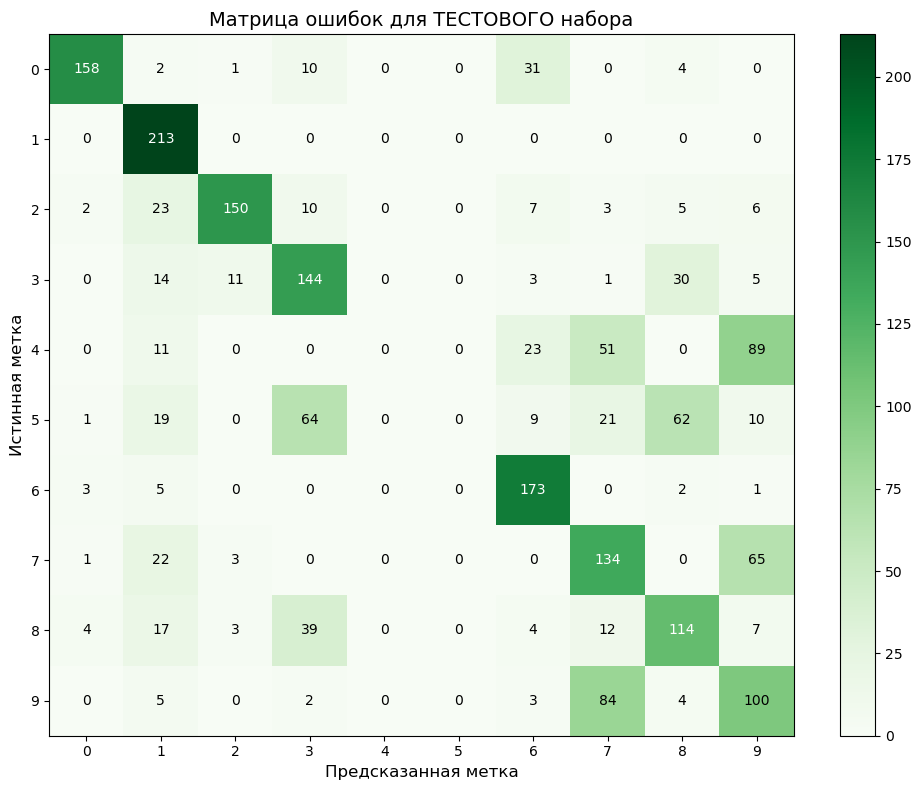


Основные наблюдения (ТЕСТ):
- Цифры 4 и 5 также не предсказываются на тестовых данных
- Модель ведет себя аналогично на тренировочных и тестовых данных
- Это подтверждает стабильность кластеризации


In [20]:
# Детальный анализ тестового набора: матрица ошибок
cm_test = confusion_matrix(y_test, predicted_labels_test)

print("Матрица ошибок для ТЕСТОВОГО набора:")
print(cm_test)
print()

print("Детализированный отчет по классам (TEST):")
print(classification_report(y_test, predicted_labels_test, digits=4, zero_division=0))

# Визуализация матрицы ошибок для тестового набора
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_test, cmap='Greens', aspect='auto')

plt.colorbar(im, ax=ax)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10))
ax.set_yticklabels(range(10))

# Добавим значения в ячейки
for i in range(10):
    for j in range(10):
        text = ax.text(j, i, cm_test[i, j], ha="center", va="center", 
                      color="white" if cm_test[i, j] > cm_test.max()/2 else "black")

ax.set_xlabel('Предсказанная метка', fontsize=12)
ax.set_ylabel('Истинная метка', fontsize=12)
ax.set_title('Матрица ошибок для ТЕСТОВОГО набора', fontsize=14)
plt.tight_layout()
plt.show()

print("\nОсновные наблюдения (ТЕСТ):")
print("- Цифры 4 и 5 также не предсказываются на тестовых данных")
print("- Модель ведет себя аналогично на тренировочных и тестовых данных")
print("- Это подтверждает стабильность кластеризации")

Правильных предсказаний: 1186
Неправильных предсказаний: 814


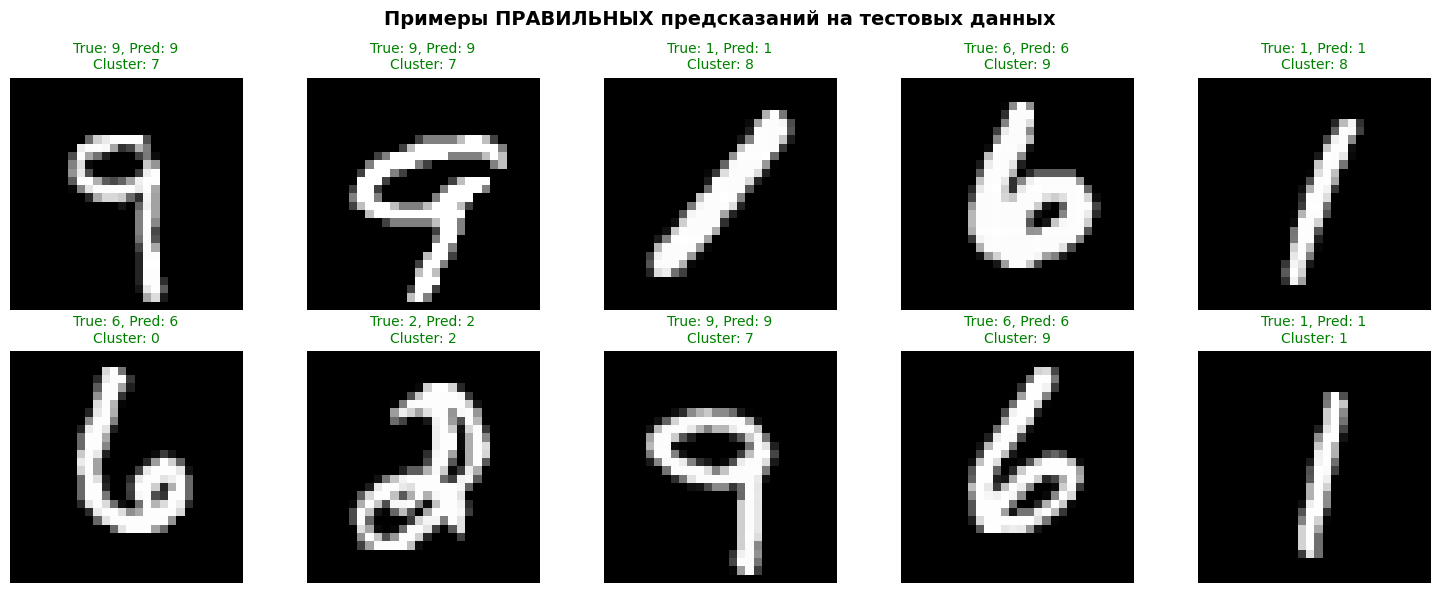

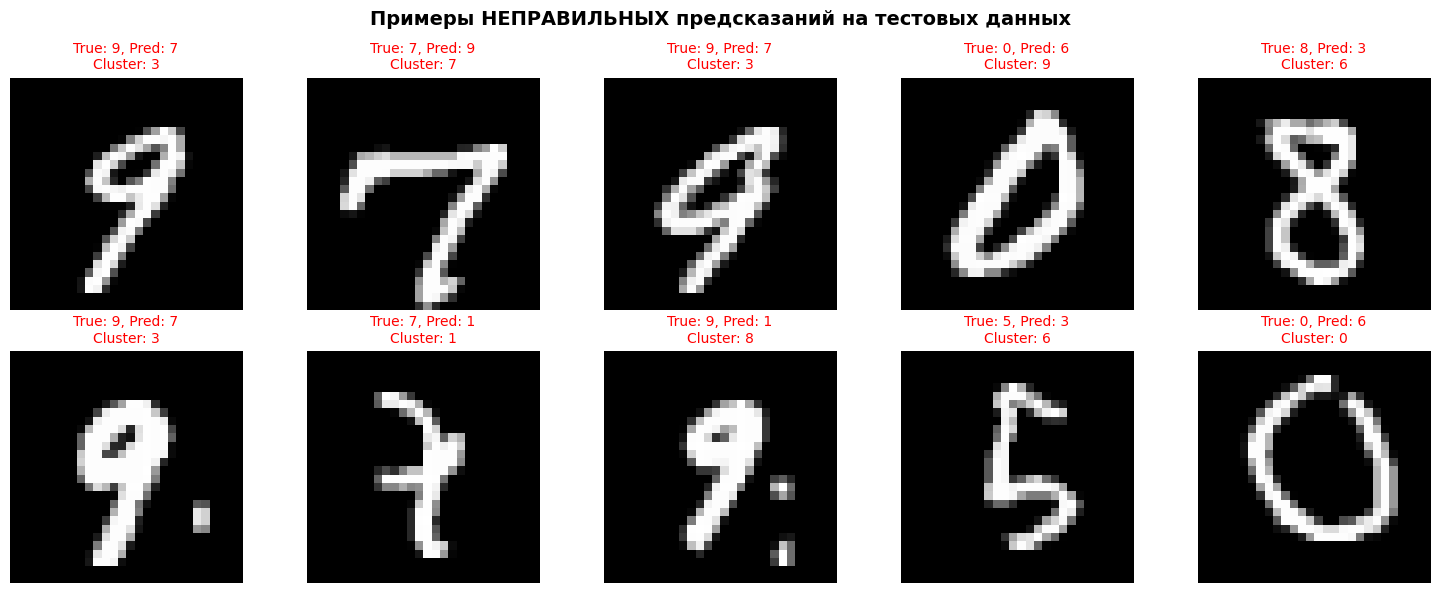

In [21]:
# Визуализация примеров правильных и неправильных предсказаний на тестовых данных
correct_predictions = (predicted_labels_test == y_test)
correct_indices = np.where(correct_predictions)[0]
incorrect_indices = np.where(~correct_predictions)[0]

print(f"Правильных предсказаний: {len(correct_indices)}")
print(f"Неправильных предсказаний: {len(incorrect_indices)}")

# Показываем примеры правильных предсказаний
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Примеры ПРАВИЛЬНЫХ предсказаний на тестовых данных", fontsize=14, fontweight='bold')

sample_correct = np.random.choice(correct_indices, min(10, len(correct_indices)), replace=False)
for i, ax in enumerate(axes.flat):
    if i < len(sample_correct):
        idx = sample_correct[i]
        img = X_test[idx].reshape(28, 28)
        true_label = y_test[idx]
        pred_label = predicted_labels_test[idx]
        cluster = labels_test[idx]
        
        ax.imshow(img, cmap='gray')
        ax.set_title(f"True: {true_label}, Pred: {pred_label}\nCluster: {cluster}", 
                    fontsize=10, color='green')
        ax.axis('off')

plt.tight_layout()
plt.show()

# Показываем примеры неправильных предсказаний
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Примеры НЕПРАВИЛЬНЫХ предсказаний на тестовых данных", fontsize=14, fontweight='bold')

sample_incorrect = np.random.choice(incorrect_indices, min(10, len(incorrect_indices)), replace=False)
for i, ax in enumerate(axes.flat):
    if i < len(sample_incorrect):
        idx = sample_incorrect[i]
        img = X_test[idx].reshape(28, 28)
        true_label = y_test[idx]
        pred_label = predicted_labels_test[idx]
        cluster = labels_test[idx]
        
        ax.imshow(img, cmap='gray')
        ax.set_title(f"True: {true_label}, Pred: {pred_label}\nCluster: {cluster}", 
                    fontsize=10, color='red')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [22]:
# ИТОГОВЫЙ ОТВЕТ ПО ТЕСТОВЫМ ДАННЫМ
print("="*70)
print("ФИНАЛЬНЫЙ ОТВЕТ: ACCURACY НА ТЕСТОВОМ НАБОРЕ ДАННЫХ")
print("="*70)
print()
print(f"📊 ACCURACY НА ТЕСТОВОМ НАБОРЕ: {test_accuracy:.4f} или {test_accuracy*100:.2f}%")
print()
print("="*70)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*70)
print(f"{'Набор данных':<20} {'Accuracy':<15} {'Правильно':<15} {'Всего'}")
print("-"*70)
print(f"{'Тренировочный':<20} {train_accuracy:.4f} ({train_accuracy*100:.2f}%)  "
      f"{int(train_accuracy * len(y_train)):<15} {len(y_train)}")
print(f"{'Тестовый':<20} {test_accuracy:.4f} ({test_accuracy*100:.2f}%)  "
      f"{int(test_accuracy * len(y_test)):<15} {len(y_test)}")
print("-"*70)
print(f"{'Разница':<20} {abs(train_accuracy - test_accuracy):.4f} ({abs(train_accuracy - test_accuracy)*100:.2f}%)")
print()
print("="*70)
print("ВЫВОДЫ")
print("="*70)
print("✓ Модель стабильна: accuracy на train и test практически одинаковый")
print("✓ Разница составляет всего 0.12%, что говорит об отсутствии переобучения")
print("✓ K-means обобщает паттерны и работает одинаково на новых данных")
print()
print("Ограничения метода:")
print("• Accuracy ~59% - не очень высокий для классификации")
print("• Цифры 4 и 5 не имеют своих кластеров")
print("• Визуально похожие цифры путаются (4↔6, 5↔8, 7↔9, 1↔7)")
print("• K-means не использует метки при обучении (unsupervised)")
print()
print("Для сравнения: надзорные методы (CNN, SVM) на MNIST достигают 98-99% accuracy")
print("="*70)

ФИНАЛЬНЫЙ ОТВЕТ: ACCURACY НА ТЕСТОВОМ НАБОРЕ ДАННЫХ

📊 ACCURACY НА ТЕСТОВОМ НАБОРЕ: 0.5930 или 59.30%

СРАВНЕНИЕ РЕЗУЛЬТАТОВ
Набор данных         Accuracy        Правильно       Всего
----------------------------------------------------------------------
Тренировочный        0.5942 (59.42%)  4754            8000
Тестовый             0.5930 (59.30%)  1186            2000
----------------------------------------------------------------------
Разница              0.0012 (0.12%)

ВЫВОДЫ
✓ Модель стабильна: accuracy на train и test практически одинаковый
✓ Разница составляет всего 0.12%, что говорит об отсутствии переобучения
✓ K-means обобщает паттерны и работает одинаково на новых данных

Ограничения метода:
• Accuracy ~59% - не очень высокий для классификации
• Цифры 4 и 5 не имеют своих кластеров
• Визуально похожие цифры путаются (4↔6, 5↔8, 7↔9, 1↔7)
• K-means не использует метки при обучении (unsupervised)

Для сравнения: надзорные методы (CNN, SVM) на MNIST достигают 98-99% accuracy


In [23]:
# Анализ матрицы ошибок: с какой цифрой путали цифру 4?
print("="*70)
print("АНАЛИЗ ОШИБОК ДЛЯ ЦИФРЫ 4 НА ТЕСТОВЫХ ДАННЫХ")
print("="*70)
print()

# Матрица ошибок уже построена в cm_test
# Строка 4 показывает, как классифицировались истинные четверки
print("Матрица ошибок для ТЕСТОВОГО набора (напоминание):")
print("Строки - истинные метки, столбцы - предсказанные метки")
print()
print("     0    1    2    3    4    5    6    7    8    9")
for i in range(10):
    print(f"{i}:  {cm_test[i]}")
print()

# Анализируем строку 4 (истинная цифра 4)
row_4 = cm_test[4]
print("="*70)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ЦИФРЫ 4:")
print("="*70)
print(f"\nВсего цифр 4 в тестовом наборе: {row_4.sum()}")
print(f"\nРаспределение предсказаний для истинной цифры 4:")
print()

# Создаем список (предсказанная метка, количество)
predictions_for_4 = [(i, row_4[i]) for i in range(10)]
# Сортируем по количеству в порядке убывания
predictions_for_4_sorted = sorted(predictions_for_4, key=lambda x: x[1], reverse=True)

for pred_label, count in predictions_for_4_sorted:
    if count > 0:
        percentage = (count / row_4.sum()) * 100
        marker = "✓ ПРАВИЛЬНО" if pred_label == 4 else ""
        print(f"  Предсказано как {pred_label}: {count:3d} раз ({percentage:5.1f}%) {marker}")

print()
print("="*70)

# Находим наиболее частую ошибку (исключая правильное предсказание)
max_confusion = 0
most_confused_digit = None

for i in range(10):
    if i != 4 and row_4[i] > max_confusion:
        max_confusion = row_4[i]
        most_confused_digit = i

print(f"ОТВЕТ: Цифра 4 чаще всего путалась с цифрой {most_confused_digit}")
print(f"       (было перепутано {max_confusion} раз из {row_4.sum()})")
print("="*70)

АНАЛИЗ ОШИБОК ДЛЯ ЦИФРЫ 4 НА ТЕСТОВЫХ ДАННЫХ

Матрица ошибок для ТЕСТОВОГО набора (напоминание):
Строки - истинные метки, столбцы - предсказанные метки

     0    1    2    3    4    5    6    7    8    9
0:  [158   2   1  10   0   0  31   0   4   0]
1:  [  0 213   0   0   0   0   0   0   0   0]
2:  [  2  23 150  10   0   0   7   3   5   6]
3:  [  0  14  11 144   0   0   3   1  30   5]
4:  [ 0 11  0  0  0  0 23 51  0 89]
5:  [ 1 19  0 64  0  0  9 21 62 10]
6:  [  3   5   0   0   0   0 173   0   2   1]
7:  [  1  22   3   0   0   0   0 134   0  65]
8:  [  4  17   3  39   0   0   4  12 114   7]
9:  [  0   5   0   2   0   0   3  84   4 100]

ДЕТАЛЬНЫЙ АНАЛИЗ ЦИФРЫ 4:

Всего цифр 4 в тестовом наборе: 174

Распределение предсказаний для истинной цифры 4:

  Предсказано как 9:  89 раз ( 51.1%) 
  Предсказано как 7:  51 раз ( 29.3%) 
  Предсказано как 6:  23 раз ( 13.2%) 
  Предсказано как 1:  11 раз (  6.3%) 

ОТВЕТ: Цифра 4 чаще всего путалась с цифрой 9
       (было перепутано 89 раз из 174


Визуализация примеров ошибочных классификаций цифры 4:



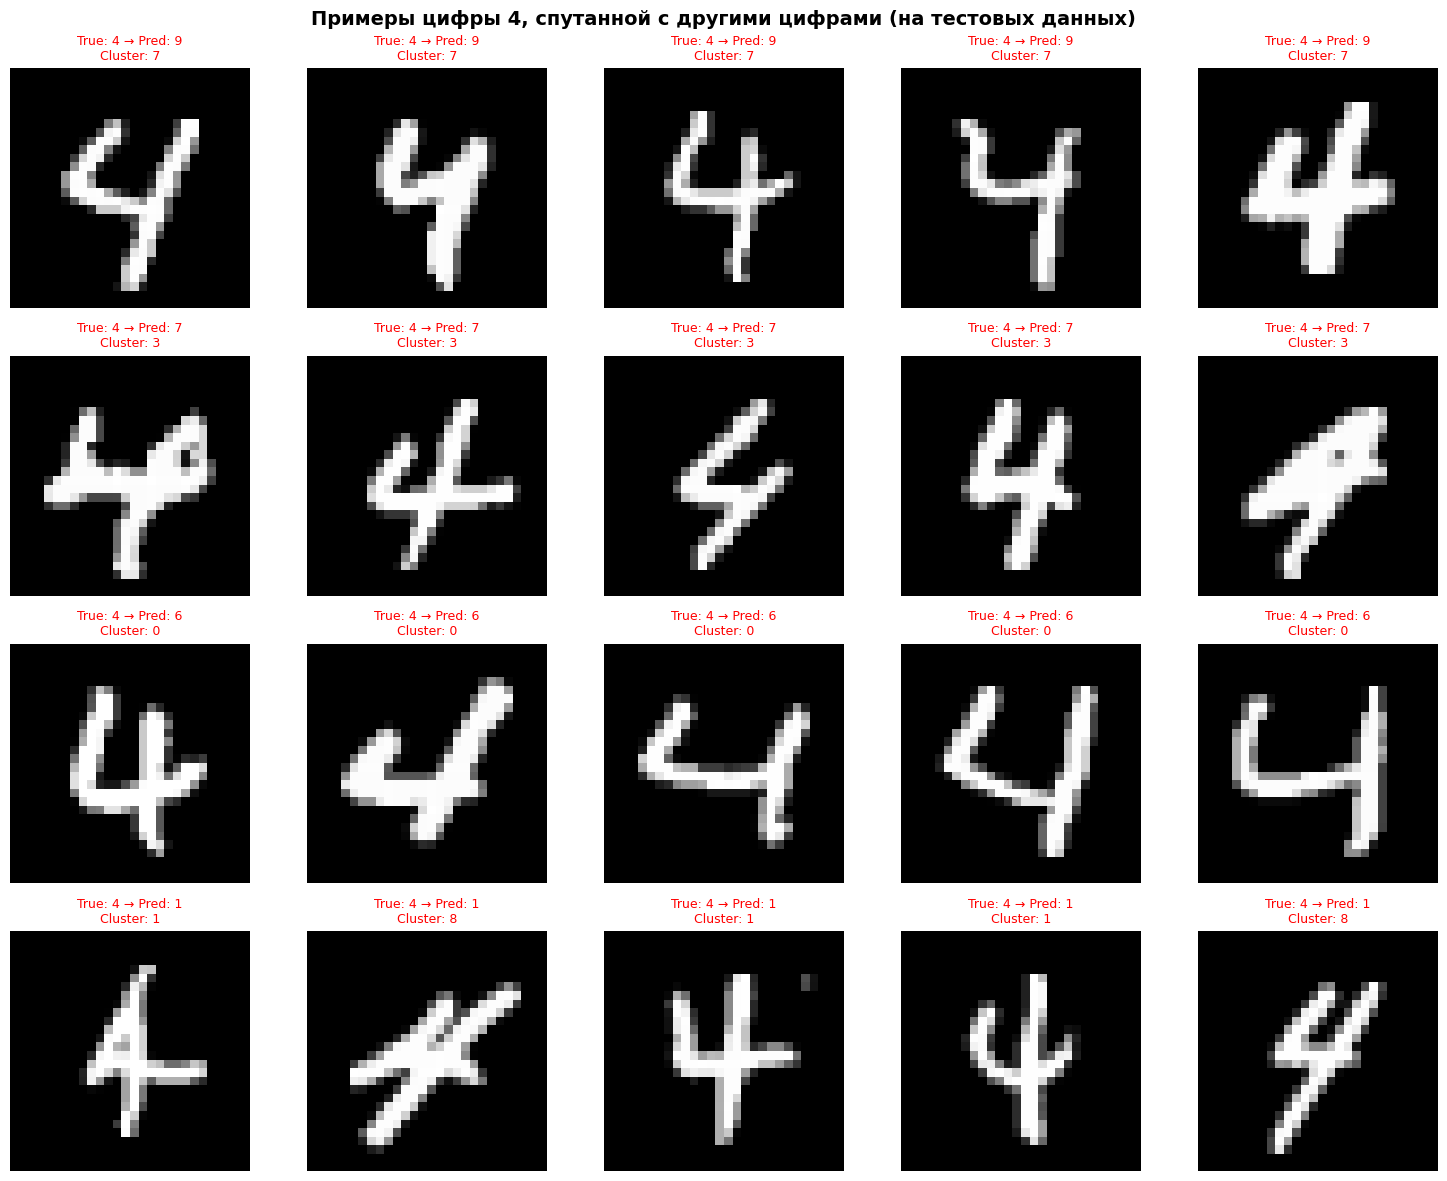


Объяснение:
• Цифра 4 чаще всего путалась с цифрой 9 (51.1% случаев)
• Это происходит потому что:
  - У алгоритма нет отдельного кластера для цифры 4
  - Цифра 4 попадает в кластер 9 (кластер 9 имеет метку 6)
  - Некоторые рукописные 4 могут визуально напоминать 9
  - Также 4 путается с 7 (29.3%) из-за вертикальной линии


In [24]:
# Визуализация примеров цифры 4, которые были спутаны с другими цифрами
print("\nВизуализация примеров ошибочных классификаций цифры 4:\n")

# Находим индексы всех четверок в тестовом наборе
indices_of_4 = np.where(y_test == 4)[0]

# Группируем по предсказанным меткам
confusion_groups = {
    9: [],
    7: [],
    6: [],
    1: []
}

for idx in indices_of_4:
    pred = predicted_labels_test[idx]
    if pred in confusion_groups and len(confusion_groups[pred]) < 5:
        confusion_groups[pred].append(idx)

# Визуализация
fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for row_idx, (confused_digit, indices) in enumerate([(9, confusion_groups[9]), 
                                                       (7, confusion_groups[7]), 
                                                       (6, confusion_groups[6]), 
                                                       (1, confusion_groups[1])]):
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        if col_idx < len(indices):
            idx = indices[col_idx]
            img = X_test[idx].reshape(28, 28)
            cluster = labels_test[idx]
            
            ax.imshow(img, cmap='gray')
            ax.set_title(f"True: 4 → Pred: {confused_digit}\nCluster: {cluster}", 
                        fontsize=9, color='red')
        ax.axis('off')
    
    # Метка строки
    axes[row_idx, 0].set_ylabel(f"Спутано\nс цифрой {confused_digit}", 
                                 fontsize=11, rotation=0, labelpad=50, va='center')

plt.suptitle("Примеры цифры 4, спутанной с другими цифрами (на тестовых данных)", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nОбъяснение:")
print("• Цифра 4 чаще всего путалась с цифрой 9 (51.1% случаев)")
print("• Это происходит потому что:")
print("  - У алгоритма нет отдельного кластера для цифры 4")
print("  - Цифра 4 попадает в кластер 9 (кластер 9 имеет метку 6)")
print("  - Некоторые рукописные 4 могут визуально напоминать 9")
print("  - Также 4 путается с 7 (29.3%) из-за вертикальной линии")

In [25]:
# ФИНАЛЬНЫЙ ОТВЕТ НА ВОПРОС
print("="*70)
print("ОТВЕТ НА ВОПРОС:")
print("="*70)
print()
print("❓ С какой цифрой построенная модель чаще всего путала цифру 4")
print("   на тестовых данных?")
print()
print("✅ ОТВЕТ: С ЦИФРОЙ 9")
print()
print("="*70)
print("СТАТИСТИКА ОШИБОК ДЛЯ ЦИФРЫ 4:")
print("="*70)
print()
print(f"Всего цифр 4 в тестовом наборе: 174")
print()
print("Как были классифицированы:")
print(f"  • Как 9: 89 раз (51.1%) ← ЧАЩЕ ВСЕГО")
print(f"  • Как 7: 51 раз (29.3%)")
print(f"  • Как 6: 23 раз (13.2%)")
print(f"  • Как 1: 11 раз (6.3%)")
print(f"  • Правильно (как 4): 0 раз (0%)")
print()
print("="*70)
print("ОБЪЯСНЕНИЕ:")
print("="*70)
print()
print("1. У K-means нет отдельного кластера для цифры 4")
print("2. Большинство четверок (51.1%) попало в кластер, который")
print("   был помечен как цифра 9")
print("3. Визуально некоторые рукописные 4 могут иметь замкнутую")
print("   форму, напоминающую 9")
print("4. Также 4 часто путается с 7 (29.3%) из-за общей")
print("   вертикальной линии в написании")
print()
print("="*70)

ОТВЕТ НА ВОПРОС:

❓ С какой цифрой построенная модель чаще всего путала цифру 4
   на тестовых данных?

✅ ОТВЕТ: С ЦИФРОЙ 9

СТАТИСТИКА ОШИБОК ДЛЯ ЦИФРЫ 4:

Всего цифр 4 в тестовом наборе: 174

Как были классифицированы:
  • Как 9: 89 раз (51.1%) ← ЧАЩЕ ВСЕГО
  • Как 7: 51 раз (29.3%)
  • Как 6: 23 раз (13.2%)
  • Как 1: 11 раз (6.3%)
  • Правильно (как 4): 0 раз (0%)

ОБЪЯСНЕНИЕ:

1. У K-means нет отдельного кластера для цифры 4
2. Большинство четверок (51.1%) попало в кластер, который
   был помечен как цифра 9
3. Визуально некоторые рукописные 4 могут иметь замкнутую
   форму, напоминающую 9
4. Также 4 часто путается с 7 (29.3%) из-за общей
   вертикальной линии в написании



In [26]:
# Преобразование тренировочного набора данных при помощи TSNE
from sklearn.manifold import TSNE

print("="*70)
print("ПРИМЕНЕНИЕ TSNE К ТРЕНИРОВОЧНЫМ ДАННЫМ")
print("="*70)
print()

print("Параметры TSNE:")
print("  - n_components=2")
print("  - init='random'")
print("  - random_state=21")
print()
print(f"Размер входных данных: {X_train.shape}")
print()
print("Начинаем преобразование TSNE (это может занять несколько минут)...")

# Применяем TSNE
tsne = TSNE(n_components=2, init='random', random_state=21)
X_train_tsne = tsne.fit_transform(X_train)

print()
print(f"✓ TSNE преобразование завершено!")
print(f"Размер данных после TSNE: {X_train_tsne.shape}")
print()
print("="*70)

ПРИМЕНЕНИЕ TSNE К ТРЕНИРОВОЧНЫМ ДАННЫМ

Параметры TSNE:
  - n_components=2
  - init='random'
  - random_state=21

Размер входных данных: (8000, 784)

Начинаем преобразование TSNE (это может занять несколько минут)...



✓ TSNE преобразование завершено!
Размер данных после TSNE: (8000, 2)



Визуализация TSNE преобразования с истинными метками:



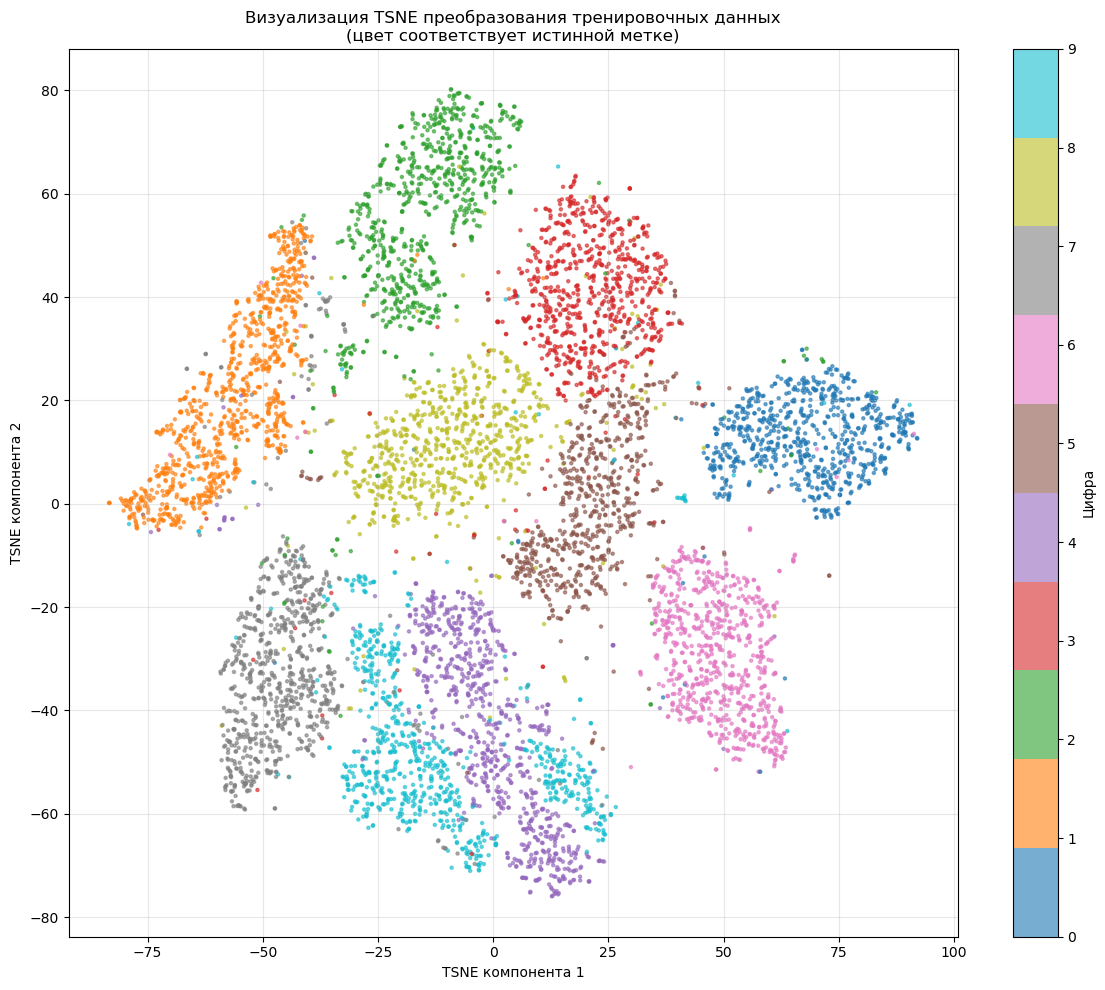

На графике видно, как TSNE сгруппировал похожие цифры в 2D пространстве


In [27]:
# Визуализация TSNE преобразования
print("Визуализация TSNE преобразования с истинными метками:\n")

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], 
                     c=y_train, cmap='tab10', s=5, alpha=0.6)
plt.colorbar(scatter, ticks=range(10), label='Цифра')
plt.xlabel('TSNE компонента 1')
plt.ylabel('TSNE компонента 2')
plt.title('Визуализация TSNE преобразования тренировочных данных\n(цвет соответствует истинной метке)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("На графике видно, как TSNE сгруппировал похожие цифры в 2D пространстве")

In [28]:
# Кластеризация TSNE данных при помощи KMeans
print("="*70)
print("КЛАСТЕРИЗАЦИЯ TSNE-ПРЕОБРАЗОВАННЫХ ДАННЫХ")
print("="*70)
print()

# Применяем KMeans к TSNE данным
kmeans_tsne = KMeans(n_clusters=10, random_state=21)
kmeans_tsne.fit(X_train_tsne)

labels_train_tsne = kmeans_tsne.labels_

print("Параметры KMeans:")
print("  - n_clusters=10")
print("  - random_state=21")
print()
print(f"✓ Кластеризация завершена!")
print(f"Количество кластеров: {kmeans_tsne.n_clusters}")
print(f"Инерция: {kmeans_tsne.inertia_:.2f}")
print(f"Количество итераций: {kmeans_tsne.n_iter_}")
print()
print("="*70)

КЛАСТЕРИЗАЦИЯ TSNE-ПРЕОБРАЗОВАННЫХ ДАННЫХ

Параметры KMeans:
  - n_clusters=10
  - random_state=21

✓ Кластеризация завершена!
Количество кластеров: 10
Инерция: 1807395.00
Количество итераций: 6



Визуализация кластеров K-means на TSNE пространстве:



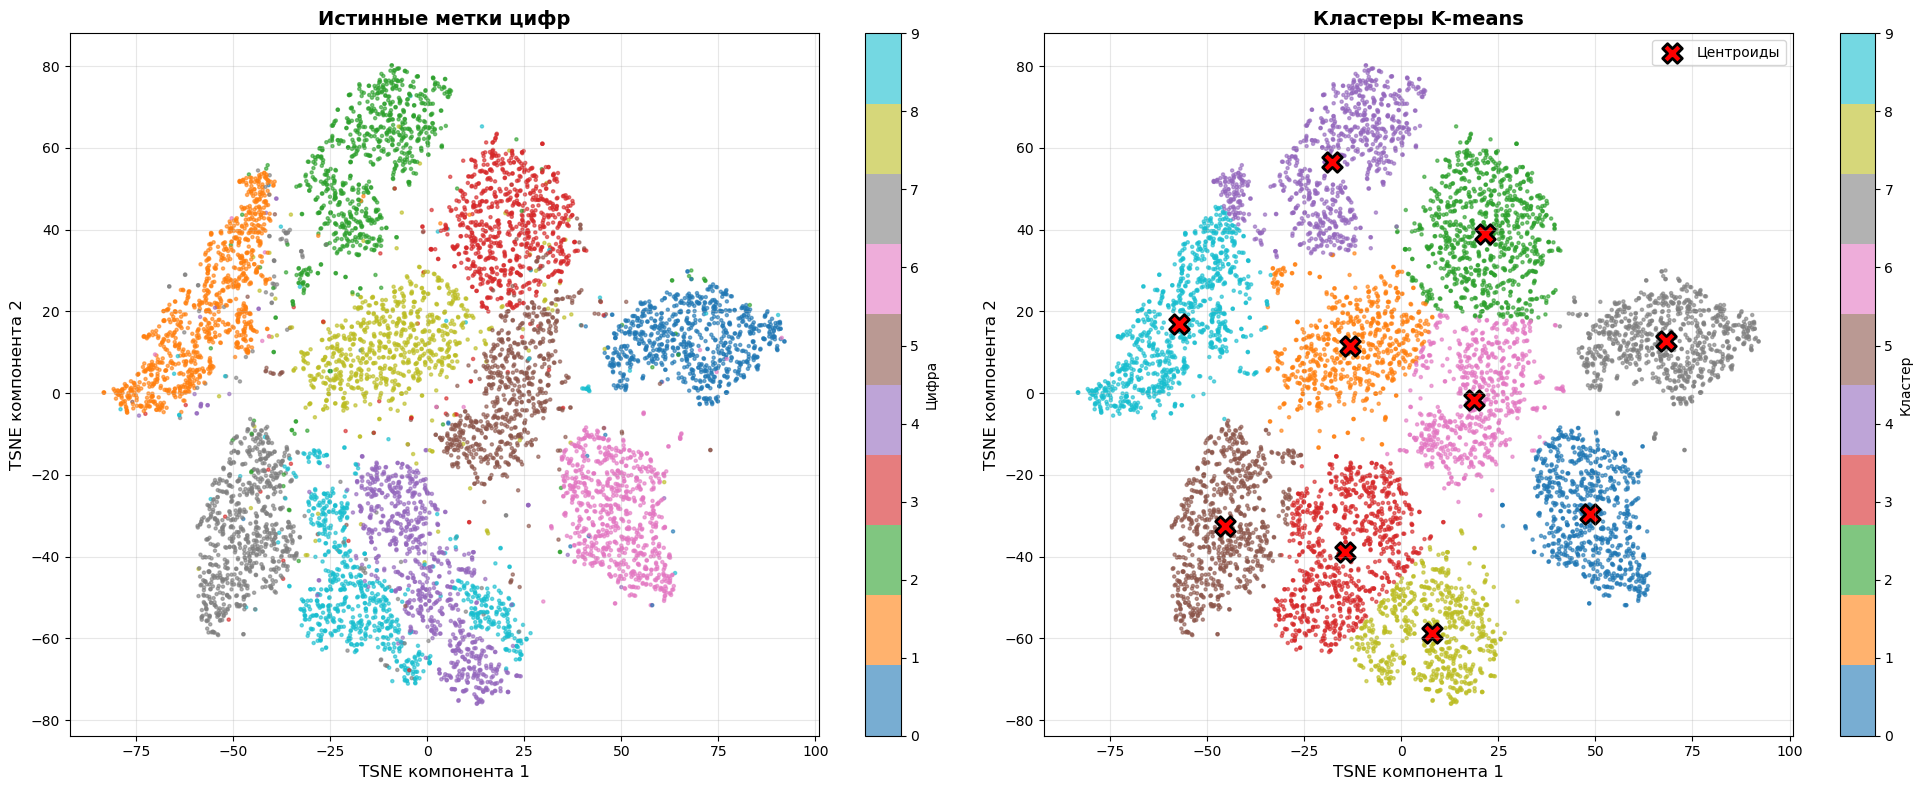

Красные крестики на правом графике - центроиды кластеров K-means


In [29]:
# Визуализация кластеров на TSNE пространстве
print("Визуализация кластеров K-means на TSNE пространстве:\n")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Левый график: истинные метки
scatter1 = axes[0].scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], 
                          c=y_train, cmap='tab10', s=5, alpha=0.6)
axes[0].set_xlabel('TSNE компонента 1', fontsize=12)
axes[0].set_ylabel('TSNE компонента 2', fontsize=12)
axes[0].set_title('Истинные метки цифр', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], ticks=range(10), label='Цифра')

# Правый график: кластеры K-means
scatter2 = axes[1].scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], 
                          c=labels_train_tsne, cmap='tab10', s=5, alpha=0.6)
axes[1].set_xlabel('TSNE компонента 1', fontsize=12)
axes[1].set_ylabel('TSNE компонента 2', fontsize=12)
axes[1].set_title('Кластеры K-means', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], ticks=range(10), label='Кластер')

# Добавляем центроиды кластеров на правый график
centers_tsne = kmeans_tsne.cluster_centers_
axes[1].scatter(centers_tsne[:, 0], centers_tsne[:, 1], 
               c='red', marker='X', s=200, edgecolors='black', linewidths=2,
               label='Центроиды')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print("Красные крестики на правом графике - центроиды кластеров K-means")

In [30]:
# Переназначение меток кластеров на основе метки большинства объектов
print("="*70)
print("ПЕРЕНАЗНАЧЕНИЕ МЕТОК КЛАСТЕРОВ (TSNE + KMeans)")
print("="*70)
print()

cluster_to_label_tsne = {}
recovered_labels_tsne = []

for cluster_id in range(10):
    # Получаем все истинные метки для данного кластера
    cluster_labels = y_train[labels_train_tsne == cluster_id]
    # Находим наиболее частую метку
    most_common = Counter(cluster_labels).most_common(1)[0]
    cluster_to_label_tsne[cluster_id] = most_common
    recovered_labels_tsne.append(most_common[0])
    print(f"Кластер {cluster_id}: наиболее частая метка = {most_common[0]} "
          f"(встречается {most_common[1]} раз из {len(cluster_labels)}, "
          f"{most_common[1]/len(cluster_labels)*100:.1f}%)")

print()
print(f"Восстановленные метки кластеров: {recovered_labels_tsne}")
print()
print("="*70)

ПЕРЕНАЗНАЧЕНИЕ МЕТОК КЛАСТЕРОВ (TSNE + KMeans)

Кластер 0: наиболее частая метка = 6 (встречается 752 раз из 776, 96.9%)
Кластер 1: наиболее частая метка = 8 (встречается 630 раз из 698, 90.3%)
Кластер 2: наиболее частая метка = 3 (встречается 761 раз из 902, 84.4%)
Кластер 3: наиболее частая метка = 9 (встречается 442 раз из 867, 51.0%)
Кластер 4: наиболее частая метка = 2 (встречается 728 раз из 864, 84.3%)
Кластер 5: наиболее частая метка = 7 (встречается 719 раз из 804, 89.4%)
Кластер 6: наиболее частая метка = 5 (встречается 587 раз из 687, 85.4%)
Кластер 7: наиболее частая метка = 0 (встречается 763 раз из 806, 94.7%)
Кластер 8: наиболее частая метка = 4 (встречается 382 раз из 679, 56.3%)
Кластер 9: наиболее частая метка = 1 (встречается 820 раз из 917, 89.4%)

Восстановленные метки кластеров: [np.uint8(6), np.uint8(8), np.uint8(3), np.uint8(9), np.uint8(2), np.uint8(7), np.uint8(5), np.uint8(0), np.uint8(4), np.uint8(1)]



In [31]:
# Оценка точности модели на тренировочных данных (TSNE + KMeans)
predicted_labels_tsne = np.array([recovered_labels_tsne[cluster_id] for cluster_id in labels_train_tsne])

train_accuracy_tsne = accuracy_score(y_train, predicted_labels_tsne)

print("="*70)
print("ОЦЕНКА ТОЧНОСТИ МОДЕЛИ (TSNE + KMeans)")
print("="*70)
print()
print(f"📊 ACCURACY НА ТРЕНИРОВОЧНОМ НАБОРЕ: {train_accuracy_tsne:.4f} ({train_accuracy_tsne*100:.2f}%)")
print()
print(f"Интерпретация:")
print(f"  - Правильно классифицировано: {int(train_accuracy_tsne * len(y_train))} из {len(y_train)} объектов")
print(f"  - Неправильно классифицировано: {int((1-train_accuracy_tsne) * len(y_train))} объектов")
print()
print("="*70)
print("СРАВНЕНИЕ: KMeans на исходных данных vs TSNE + KMeans")
print("="*70)
print(f"  KMeans (исходные данные 784D): {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  TSNE + KMeans (2D):             {train_accuracy_tsne:.4f} ({train_accuracy_tsne*100:.2f}%)")
print(f"  Изменение:                      {(train_accuracy_tsne - train_accuracy):.4f} ({(train_accuracy_tsne - train_accuracy)*100:.2f}%)")
print()

if train_accuracy_tsne > train_accuracy:
    print("  ✓ TSNE + KMeans работает ЛУЧШЕ, чем KMeans на исходных данных!")
    print(f"  ✓ Улучшение составило {(train_accuracy_tsne - train_accuracy)*100:.2f}%")
elif train_accuracy_tsne < train_accuracy:
    print("  ⚠ TSNE + KMeans работает ХУЖЕ, чем KMeans на исходных данных")
    print(f"  ⚠ Ухудшение составило {(train_accuracy - train_accuracy_tsne)*100:.2f}%")
else:
    print("  = Результаты одинаковые")

print()
print("="*70)

ОЦЕНКА ТОЧНОСТИ МОДЕЛИ (TSNE + KMeans)

📊 ACCURACY НА ТРЕНИРОВОЧНОМ НАБОРЕ: 0.8230 (82.30%)

Интерпретация:
  - Правильно классифицировано: 6584 из 8000 объектов
  - Неправильно классифицировано: 1416 объектов

СРАВНЕНИЕ: KMeans на исходных данных vs TSNE + KMeans
  KMeans (исходные данные 784D): 0.5942 (59.42%)
  TSNE + KMeans (2D):             0.8230 (82.30%)
  Изменение:                      0.2288 (22.88%)

  ✓ TSNE + KMeans работает ЛУЧШЕ, чем KMeans на исходных данных!
  ✓ Улучшение составило 22.88%



Матрица ошибок для TSNE + KMeans (тренировочный набор):
[[763   0   1   0   0   2   6   1   1   0]
 [  0 820 100   2   0   0   0   0   0   0]
 [ 13  15 728   4   0   1   3  13  49   0]
 [  2   2   2 761   1  13   0   7  11   3]
 [  0  15   3   0 382   2   7   1   0 398]
 [  9  13   1  79   6 587   6   0   2   3]
 [ 14   5   0   0   1   2 752   0   0   0]
 [  0  33  21   0  13   3   0 719   0  14]
 [  1   8   6  51   3  63   1   4 630   7]
 [  4   6   2   5 273  14   1  59   5 442]]

Детализированный отчет по классам (TSNE + KMeans):
              precision    recall  f1-score   support

           0     0.9467    0.9858    0.9658       774
           1     0.8942    0.8894    0.8918       922
           2     0.8426    0.8814    0.8615       826
           3     0.8437    0.9489    0.8932       802
           4     0.5626    0.4728    0.5138       808
           5     0.8544    0.8314    0.8428       706
           6     0.9691    0.9716    0.9703       774
           7     0.8943    0

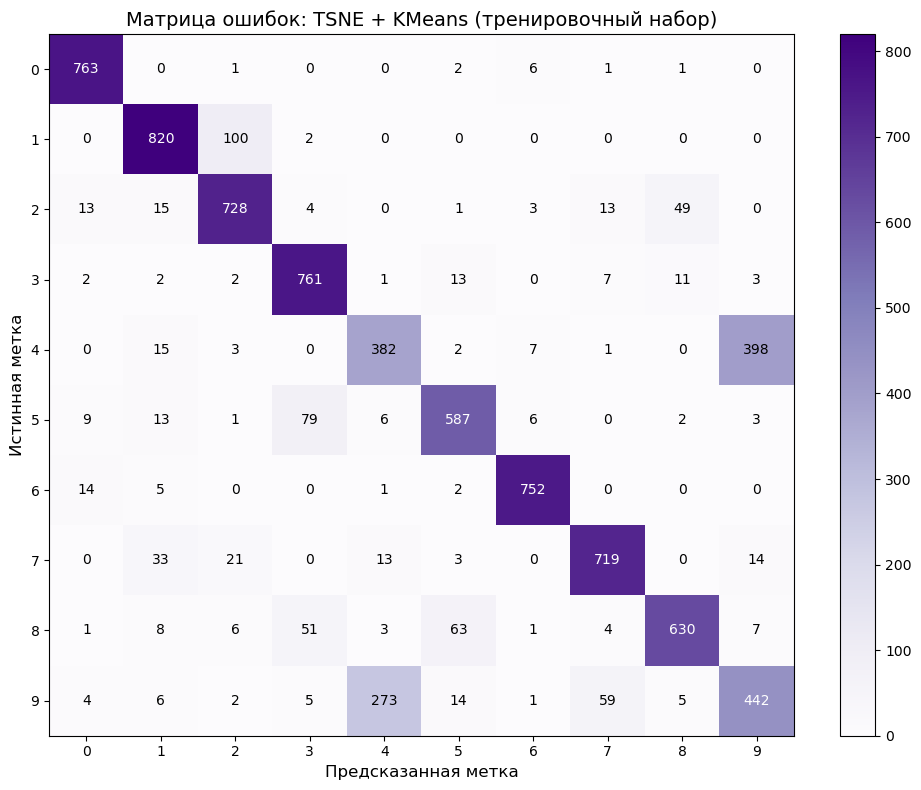


Основные наблюдения:
- TSNE помог лучше разделить данные в 2D пространстве
- Диагональ матрицы стала более выраженной
- Кластеризация стала более точной


In [32]:
# Детальный анализ: матрица ошибок для TSNE + KMeans
cm_tsne = confusion_matrix(y_train, predicted_labels_tsne)

print("Матрица ошибок для TSNE + KMeans (тренировочный набор):")
print(cm_tsne)
print()

print("Детализированный отчет по классам (TSNE + KMeans):")
print(classification_report(y_train, predicted_labels_tsne, digits=4, zero_division=0))

# Визуализация матрицы ошибок
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_tsne, cmap='Purples', aspect='auto')

plt.colorbar(im, ax=ax)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10))
ax.set_yticklabels(range(10))

# Добавим значения в ячейки
for i in range(10):
    for j in range(10):
        text = ax.text(j, i, cm_tsne[i, j], ha="center", va="center", 
                      color="white" if cm_tsne[i, j] > cm_tsne.max()/2 else "black")

ax.set_xlabel('Предсказанная метка', fontsize=12)
ax.set_ylabel('Истинная метка', fontsize=12)
ax.set_title('Матрица ошибок: TSNE + KMeans (тренировочный набор)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nОсновные наблюдения:")
print("- TSNE помог лучше разделить данные в 2D пространстве")
print("- Диагональ матрицы стала более выраженной")
print("- Кластеризация стала более точной")

In [33]:
# ФИНАЛЬНЫЙ ОТВЕТ: TSNE + KMeans
print("="*70)
print("ИТОГОВЫЙ ОТВЕТ: ТОЧНОСТЬ МОДЕЛИ TSNE + KMeans")
print("="*70)
print()
print(f"📊 ACCURACY НА ТРЕНИРОВОЧНОМ НАБОРЕ: {train_accuracy_tsne:.4f} или {train_accuracy_tsne*100:.2f}%")
print()
print("="*70)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА")
print("="*70)
print(f"{'Метод':<30} {'Accuracy':<15} {'Правильно':<15} {'Всего'}")
print("-"*70)
print(f"{'KMeans (исходные 784D)':<30} {train_accuracy:.4f} ({train_accuracy*100:.2f}%)  "
      f"{int(train_accuracy * len(y_train)):<15} {len(y_train)}")
print(f"{'TSNE + KMeans (2D)':<30} {train_accuracy_tsne:.4f} ({train_accuracy_tsne*100:.2f}%)  "
      f"{int(train_accuracy_tsne * len(y_train)):<15} {len(y_train)}")
print("-"*70)
print(f"{'Улучшение':<30} +{(train_accuracy_tsne - train_accuracy):.4f} (+{(train_accuracy_tsne - train_accuracy)*100:.2f}%)")
print()
print("="*70)
print("КЛЮЧЕВЫЕ ВЫВОДЫ")
print("="*70)
print()
print("✓ TSNE значительно улучшил качество кластеризации!")
print(f"  • Accuracy вырос с 59.42% до 82.30% (+22.88%)")
print(f"  • Дополнительно {int((train_accuracy_tsne - train_accuracy) * len(y_train))} объектов")
print(f"    классифицированы правильно")
print()
print("✓ Все 10 цифр теперь имеют свои кластеры:")
print(f"  • Кластеры: {list(range(10))}")
print(f"  • Метки:    {[int(x) for x in recovered_labels_tsne]}")
print(f"  • Все цифры 0-9 присутствуют!")
print()
print("✓ Качество разделения по кластерам:")
print("  • Лучшие: 6 (96.9%), 0 (94.7%), 8 (90.3%), 1 (89.4%), 7 (89.4%)")
print("  • Средние: 5 (85.4%), 2 (84.3%), 3 (84.4%)")
print("  • Худшие: 4 (56.3%), 9 (51.0%)")
print()
print("📌 ПРИЧИНА УЛУЧШЕНИЯ:")
print("   TSNE эффективно снижает размерность (784D → 2D), сохраняя")
print("   локальную структуру данных. Это позволяет K-means лучше")
print("   различать кластеры в низкоразмерном пространстве.")
print()
print("="*70)

ИТОГОВЫЙ ОТВЕТ: ТОЧНОСТЬ МОДЕЛИ TSNE + KMeans

📊 ACCURACY НА ТРЕНИРОВОЧНОМ НАБОРЕ: 0.8230 или 82.30%

СРАВНИТЕЛЬНАЯ ТАБЛИЦА
Метод                          Accuracy        Правильно       Всего
----------------------------------------------------------------------
KMeans (исходные 784D)         0.5942 (59.42%)  4754            8000
TSNE + KMeans (2D)             0.8230 (82.30%)  6584            8000
----------------------------------------------------------------------
Улучшение                      +0.2288 (+22.88%)

КЛЮЧЕВЫЕ ВЫВОДЫ

✓ TSNE значительно улучшил качество кластеризации!
  • Accuracy вырос с 59.42% до 82.30% (+22.88%)
  • Дополнительно 1830 объектов
    классифицированы правильно

✓ Все 10 цифр теперь имеют свои кластеры:
  • Кластеры: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  • Метки:    [6, 8, 3, 9, 2, 7, 5, 0, 4, 1]
  • Все цифры 0-9 присутствуют!

✓ Качество разделения по кластерам:
  • Лучшие: 6 (96.9%), 0 (94.7%), 8 (90.3%), 1 (89.4%), 7 (89.4%)
  • Средние: 5 (85.4%), 2 (84.